In [14]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

%matplotlib inline

X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

X

array([[-8.55383304, -1.89169935],
       [ 2.80503425, -8.74475462],
       [ 2.2613102 , -6.10552502],
       ...,
       [-7.15424927, -2.43825004],
       [ 4.05737854, -6.22501615],
       [ 3.19094963, -5.65872545]])

In [16]:
y

array([0, 1, 1, 1, 2, 2, 2, 1, 1, 2, 0, 0, 0, 2, 1, 1, 2, 0, 0, 0, 2, 2,
       0, 0, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 1, 0, 2,
       0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2,
       1, 2, 1, 2, 1, 1, 2, 1, 0, 2, 1, 1, 1, 2, 0, 0, 0, 0, 1, 0, 2, 1,
       1, 1, 1, 2, 2, 1, 2, 1, 2, 0, 1, 1, 1, 1, 2, 1, 0, 0, 1, 0, 0, 2,
       2, 0, 1, 0, 0, 1, 1, 2, 0, 2, 0, 2, 0, 1, 0, 0, 1, 2, 2, 1, 0, 0,
       0, 0, 0, 2, 1, 1, 0, 0, 1, 1, 2, 1, 1, 0, 1, 0, 0, 1, 2, 0, 2, 2,
       1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 1, 0, 1, 1, 0, 0, 2, 1, 2, 1, 1,
       1, 2, 0, 2, 0, 2, 2, 2, 1, 1, 0, 0, 1, 0, 1, 2, 2, 0, 0, 2, 2, 1,
       2, 1, 0, 0, 0, 0, 1, 1, 0, 0, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 1,
       1, 1, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 0, 1, 1, 1, 0, 0, 2, 0, 1, 2,
       1, 2, 1, 1, 1, 2, 2, 1, 1, 2, 2, 0, 0, 2, 2, 0, 1, 2, 1, 1, 1, 2,
       1, 1, 0, 2, 2, 2, 2, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 2, 2, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 2, 2, 1, 1, 1, 2, 1, 2,

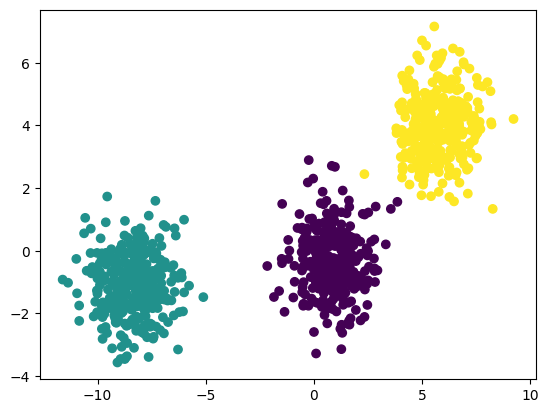

In [ ]:
plt.scatter(X[:, 0], X[:, 1],c=y)   

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.cluster import KMeans

# Elbow method to select K value
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

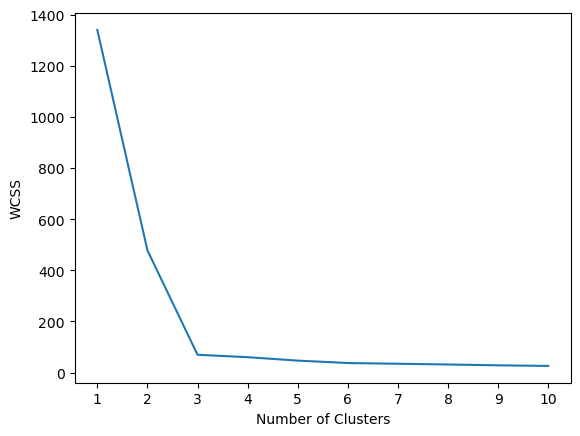

In [9]:
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, init="k-means++")

kmeans.fit_predict(X_train_scaled)

array([1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 0,
       1, 1, 1, 1, 2, 2, 1, 0, 1, 1, 2, 1, 2, 1, 0, 2, 1, 2, 0, 0, 2, 0,
       2, 2, 2, 1, 2, 0, 0, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 2, 2, 0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 2, 0, 2, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 1,
       0, 1, 0, 0, 2, 0, 1, 0, 2, 0, 1, 0, 2, 1, 1, 2, 2, 0, 1, 0, 2, 0,
       1, 1, 2, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 1, 2, 0,
       2, 1, 0, 2, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 0, 1, 2, 0, 1, 2, 2, 1,
       0, 1, 1, 1, 2, 1, 0, 1, 1, 0, 0, 2, 2, 0, 0, 1, 0, 2, 1, 1, 2, 1,
       0, 0, 2, 1, 1, 0, 1, 2, 0, 1, 1, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 2, 2, 1, 0, 0, 1, 1, 2, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 2, 0,
       2, 2, 1, 1, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 2, 2, 2, 1, 0, 1, 2,
       2, 1, 1, 1, 2, 2, 1, 0, 0, 2, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 2, 1,
       0, 0, 2, 2, 2, 2, 0, 0, 0, 1, 2, 0, 2, 1, 2,

In [7]:
y_pred = kmeans.predict(X_test_scaled)

In [11]:
y_pred

array([0, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2, 1, 2, 0, 1, 0, 2, 1, 2,
       1, 1, 0, 0, 0, 2, 1, 1, 0, 2, 1, 1, 0, 1, 0, 2, 1, 2, 1, 0, 0, 1,
       0, 2, 2, 2, 1, 2, 0, 0, 2, 2, 0, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 2,
       0, 0, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 1, 0, 0, 2, 1,
       2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 1, 0, 2,
       0, 1, 2, 1, 2, 1, 1, 1, 2, 0, 0, 2, 1, 0, 2, 2, 1, 0, 2, 0, 2, 2,
       1, 0, 0, 2, 0, 0, 1, 1, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 2, 0,
       0, 1, 0, 1, 1, 2, 1, 2, 2, 1, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 2, 2,
       1, 2, 1, 1, 1, 0, 2, 1, 2, 1, 0, 2, 0, 1, 1, 2, 1, 1, 1, 0, 0, 1,
       1, 2, 2, 2, 2, 1, 0, 2, 0, 2, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 2, 2,
       0, 2, 0, 1, 2, 1, 0, 1, 0, 2, 0, 0, 1, 0, 1, 2, 0, 1, 2, 1, 0, 2,
       0, 1, 1, 0, 2, 2, 2, 1, 0, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 2, 2,
       1, 0, 1, 2, 0, 0, 2, 2, 1, 1, 2, 0, 0, 1, 2,